# DCGAN + Autoencoder + VAE Practical
### Fashion-MNIST DCGAN and MNIST AE/VAE

**Objective:** Implement and study a Deep Convolutional GAN (DCGAN) on Fashion-MNIST, then implement a normal Autoencoder and a Variational Autoencoder (VAE) on MNIST.

This notebook follows the assignment requirements:
- DCGAN: 25 epochs, 4×4 generated-image grids every 5 epochs, generator/discriminator losses and observations.
- Normal AE: MNIST, sigmoid output, 15 epochs, latent-space visualization.
- VAE: convolutional encoder/decoder, 2-D latent space, reconstruction + KL loss, 20 epochs, reconstruction examples, latent-space visualization, latent-space generation and extreme/outside points.

The VAE encoder/decoder design follows the convolutional architecture described by GeeksforGeeks: Conv2D encoder blocks, mean/log-variance outputs, sampling, and Conv2DTranspose decoder blocks. citeturn0search0

## 1. Import Libraries and Set Parameters

In [1]:
import os
import random
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

print("TensorFlow version:", tf.__version__)
print("GPU available:", tf.config.list_physical_devices("GPU"))

OUTPUT_DIR = "gan_vae_outputs"
os.makedirs(OUTPUT_DIR, exist_ok=True)

BATCH_SIZE = 128
GAN_EPOCHS = 25
LATENT_DIM_GAN = 100

print("Output directory:", OUTPUT_DIR)

TensorFlow version: 2.20.0
GPU available: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]
Output directory: gan_vae_outputs


# Part A — DCGAN on Fashion-MNIST

## 2. Load Fashion-MNIST and Normalize to -1 to +1

The DCGAN generator ends with `tanh`, so the training images are scaled to the same `[-1, 1]` range.

In [2]:
(x_train_fashion, y_train_fashion), (x_test_fashion, y_test_fashion) = keras.datasets.fashion_mnist.load_data()

x_train_fashion = x_train_fashion.astype("float32")
x_train_fashion = (x_train_fashion - 127.5) / 127.5
x_train_fashion = np.expand_dims(x_train_fashion, axis=-1)

fashion_ds = (
    tf.data.Dataset.from_tensor_slices(x_train_fashion)
    .shuffle(60000, seed=SEED)
    .batch(BATCH_SIZE, drop_remainder=True)
    .prefetch(tf.data.AUTOTUNE)
)

print("Training shape:", x_train_fashion.shape)
print("Pixel range:", x_train_fashion.min(), "to", x_train_fashion.max())

29515/29515 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
26421880/26421880 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
5148/5148 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
4422102/4422102 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Training shape: (60000, 28, 28, 1)
Pixel range: -1.0 to 1.0


## 3. Display Original Fashion-MNIST Images

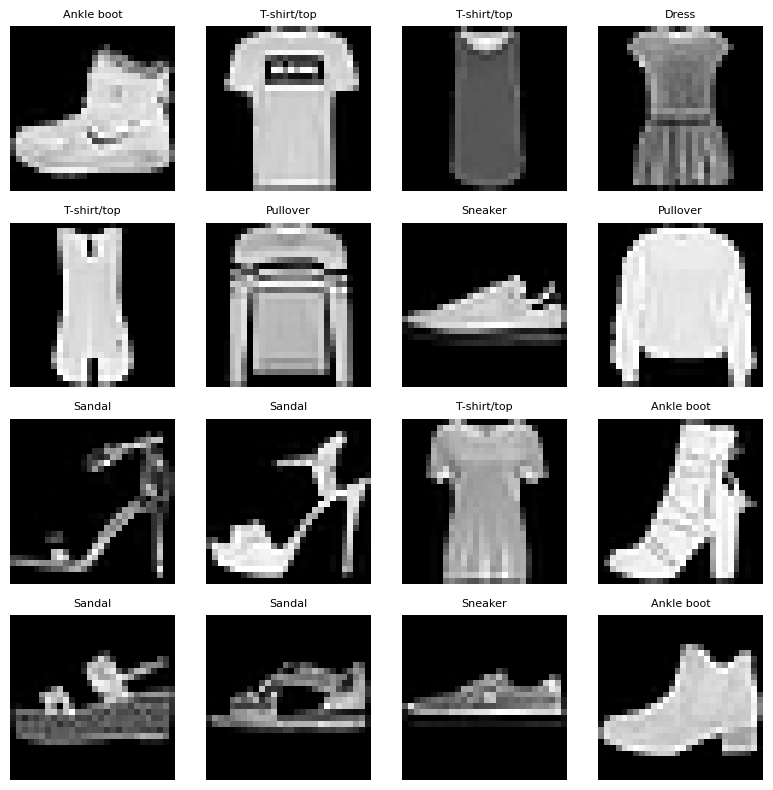

In [3]:
class_names = [
    "T-shirt/top", "Trouser", "Pullover", "Dress", "Coat",
    "Sandal", "Shirt", "Sneaker", "Bag", "Ankle boot"
]

plt.figure(figsize=(8, 8))
for i in range(16):
    plt.subplot(4, 4, i + 1)
    plt.imshow((x_train_fashion[i, :, :, 0] + 1) / 2, cmap="gray")
    plt.title(class_names[y_train_fashion[i]], fontsize=8)
    plt.axis("off")
plt.tight_layout()
plt.show()

## 4. Hardcoded Noise Vector

The same fixed noise is used after every 5 epochs so the progression can be compared fairly. A random noise vector is also used for generating fresh samples.

In [4]:
fixed_noise = tf.random.normal([16, LATENT_DIM_GAN], seed=SEED)

# One explicit hardcoded noise vector, as requested.
hardcoded_noise_vector = np.array([[
    -0.81, 0.32, -1.14, 0.55, 0.07, -0.44, 1.02, -0.18, 0.63, -0.72,
    0.29, 0.91, -0.35, 0.14, -0.67, 0.48, 0.11, -0.93, 0.76, -0.21,
    0.38, -0.57, 0.84, -0.09, 0.46, -0.31, 0.68, -0.74, 0.19, 0.52,
    -0.12, 0.97, -0.64, 0.27, 0.73, -0.49, 0.05, -0.88, 0.41, 0.16,
    -0.59, 0.79, -0.23, 0.36, -0.95, 0.62, -0.07, 0.51, -0.39, 0.86,
    -0.16, 0.24, -0.69, 0.44, 0.03, -0.52, 0.71, -0.28, 0.94, -0.61,
    0.13, -0.47, 0.58, -0.82, 0.34, 0.08, -0.73, 0.49, -0.15, 0.66,
    -0.37, 0.92, -0.05, 0.31, -0.56, 0.77, -0.19, 0.43, -0.87, 0.22,
    0.64, -0.34, 0.17, -0.71, 0.54, -0.11, 0.83, -0.26, 0.39, -0.62,
    0.06, 0.47, -0.91, 0.28, 0.75, -0.43, 0.12, -0.58, 0.69, -0.08
]], dtype="float32")

print("Hardcoded vector shape:", hardcoded_noise_vector.shape)

Hardcoded vector shape: (1, 100)


## 5. Build the Generator

The generator starts from random noise and uses transposed convolution layers to increase spatial resolution from 7×7 to 14×14 and finally 28×28. The final activation is `tanh`.

In [5]:
def build_generator(latent_dim=100):
    model = keras.Sequential(name="Generator")
    model.add(layers.Input(shape=(latent_dim,)))
    model.add(layers.Dense(7 * 7 * 256, use_bias=False))
    model.add(layers.BatchNormalization())
    model.add(layers.ReLU())
    model.add(layers.Reshape((7, 7, 256)))

    model.add(layers.Conv2DTranspose(128, kernel_size=5, strides=1,
                                     padding="same", use_bias=False))
    model.add(layers.BatchNormalization())
    model.add(layers.ReLU())

    model.add(layers.Conv2DTranspose(64, kernel_size=5, strides=2,
                                     padding="same", use_bias=False))
    model.add(layers.BatchNormalization())
    model.add(layers.ReLU())

    model.add(layers.Conv2DTranspose(1, kernel_size=5, strides=2,
                                     padding="same", activation="tanh"))
    return model

generator = build_generator(LATENT_DIM_GAN)
generator.summary()

Model: "Generator"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 12544)          │     1,254,400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 12544)          │        50,176 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu (ReLU)                    │ (None, 12544)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ reshape (Reshape)               │ (None, 7, 7, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_transpose                │ (None, 7, 7, 128)      │       819,200 │
│ (Conv2DTranspose)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 7, 7, 128)      │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu_1 (ReLU)                  │ (None, 7, 7, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_transpose_1              │ (None, 14, 14, 64)     │       204,800 │
│ (Conv2DTranspose)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 14, 14, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu_2 (ReLU)                  │ (None, 14, 14, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_transpose_2              │ (None, 28, 28, 1)      │         1,601 │
│ (Conv2DTranspose)               │                        │               │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,330,945 (8.89 MB)

 Trainable params: 2,305,473 (8.79 MB)

 Non-trainable params: 25,472 (99.50 KB)

## 6. Test the Generator Before Training

Expected result: an image-like output dominated by noise because the generator has not learned the Fashion-MNIST distribution yet.

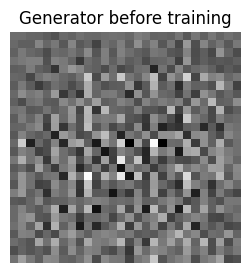

In [6]:
generated_before_training = generator(hardcoded_noise_vector, training=False)

plt.figure(figsize=(3, 3))
plt.imshow((generated_before_training[0, :, :, 0] + 1) / 2, cmap="gray")
plt.title("Generator before training")
plt.axis("off")
plt.show()

## 7. Build the Discriminator

The discriminator uses convolutional layers and outputs a single probability:
- `1` → real
- `0` → fake

A sigmoid output is used as required.

In [7]:
def build_discriminator():
    model = keras.Sequential(name="Discriminator")
    model.add(layers.Input(shape=(28, 28, 1)))

    model.add(layers.Conv2D(64, kernel_size=5, strides=2, padding="same"))
    model.add(layers.LeakyReLU(alpha=0.2))
    model.add(layers.Dropout(0.3))

    model.add(layers.Conv2D(128, kernel_size=5, strides=2, padding="same"))
    model.add(layers.LeakyReLU(alpha=0.2))
    model.add(layers.Dropout(0.3))

    model.add(layers.Flatten())
    model.add(layers.Dense(1, activation="sigmoid"))
    return model

discriminator = build_discriminator()
discriminator.summary()

/usr/local/lib/python3.13/dist-packages/keras/src/layers/activations/leaky_relu.py:41: UserWarning: Argument `alpha` is deprecated. Use `negative_slope` instead.
  warnings.warn(


Model: "Discriminator"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 14, 14, 64)     │         1,664 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu (LeakyReLU)         │ (None, 14, 14, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 14, 14, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 7, 7, 128)      │       204,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_1 (LeakyReLU)       │ (None, 7, 7, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 7, 7, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 6272)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │         6,273 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 212,865 (831.50 KB)

 Trainable params: 212,865 (831.50 KB)

 Non-trainable params: 0 (0.00 B)

## 8. Test the Discriminator

In [8]:
real_batch = next(iter(fashion_ds))
fake_batch = generator(tf.random.normal([BATCH_SIZE, LATENT_DIM_GAN]), training=False)

real_scores = discriminator(real_batch, training=False)
fake_scores = discriminator(fake_batch, training=False)

print("Real-image score example:", float(real_scores[0]))
print("Fake-image score example:", float(fake_scores[0]))

Real-image score example: 0.5284633040428162
Fake-image score example: 0.499957799911499


## 9. Loss Function and Optimizers

Binary Cross-Entropy is used for both networks. The generator is trained so that fake images are classified as real (`1`).

In [9]:
bce = keras.losses.BinaryCrossentropy(from_logits=False)

def discriminator_loss(real_output, fake_output):
    real_loss = bce(tf.ones_like(real_output), real_output)
    fake_loss = bce(tf.zeros_like(fake_output), fake_output)
    return real_loss + fake_loss

def generator_loss(fake_output):
    return bce(tf.ones_like(fake_output), fake_output)

generator_optimizer = keras.optimizers.Adam(learning_rate=2e-4, beta_1=0.5)
discriminator_optimizer = keras.optimizers.Adam(learning_rate=2e-4, beta_1=0.5)

## 10. Training Step

In [10]:
@tf.function
def train_step(images):
    noise = tf.random.normal([BATCH_SIZE, LATENT_DIM_GAN])

    with tf.GradientTape() as gen_tape, tf.GradientTape() as disc_tape:
        generated_images = generator(noise, training=True)

        real_output = discriminator(images, training=True)
        fake_output = discriminator(generated_images, training=True)

        g_loss = generator_loss(fake_output)
        d_loss = discriminator_loss(real_output, fake_output)

    gradients_of_generator = gen_tape.gradient(
        g_loss, generator.trainable_variables
    )
    gradients_of_discriminator = disc_tape.gradient(
        d_loss, discriminator.trainable_variables
    )

    generator_optimizer.apply_gradients(
        zip(gradients_of_generator, generator.trainable_variables)
    )
    discriminator_optimizer.apply_gradients(
        zip(gradients_of_discriminator, discriminator.trainable_variables)
    )

    return g_loss, d_loss

## 11. Helper to Save a 4×4 Generated Image Grid

In [11]:
gan_history = {"generator": [], "discriminator": []}
gan_snapshots = {}

def save_generated_grid(epoch):
    predictions = generator(fixed_noise, training=False)

    fig = plt.figure(figsize=(6, 6))
    for i in range(16):
        plt.subplot(4, 4, i + 1)
        plt.imshow((predictions[i, :, :, 0] + 1) / 2, cmap="gray")
        plt.axis("off")

    plt.suptitle(f"DCGAN Generated Images — Epoch {epoch}")
    plt.tight_layout(rect=[0, 0, 1, 0.96])

    path = os.path.join(OUTPUT_DIR, f"dcgan_epoch_{epoch:02d}.png")
    plt.savefig(path, dpi=150, bbox_inches="tight")
    plt.show()
    plt.close(fig)

    gan_snapshots[epoch] = predictions.numpy()
    return path

## 12. Train the DCGAN for 25 Epochs

Generated image grids are saved at epochs 5, 10, 15, 20 and 25. Generator and discriminator losses are recorded for every epoch.

Epoch 01/25 | Generator Loss: 0.7468 | Discriminator Loss: 1.2753
Epoch 02/25 | Generator Loss: 0.8008 | Discriminator Loss: 1.2750
Epoch 03/25 | Generator Loss: 0.8260 | Discriminator Loss: 1.2384
Epoch 04/25 | Generator Loss: 0.7766 | Discriminator Loss: 1.3131
Epoch 05/25 | Generator Loss: 0.7475 | Discriminator Loss: 1.3410


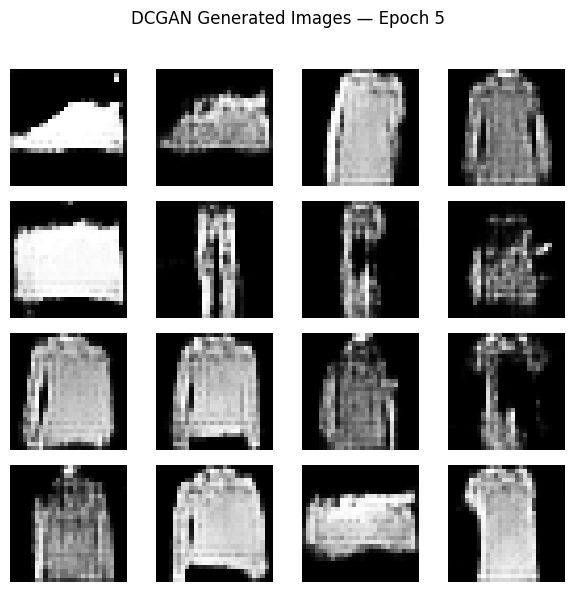

Epoch 06/25 | Generator Loss: 0.7479 | Discriminator Loss: 1.3365
Epoch 07/25 | Generator Loss: 0.7436 | Discriminator Loss: 1.3421
Epoch 08/25 | Generator Loss: 0.7342 | Discriminator Loss: 1.3524
Epoch 09/25 | Generator Loss: 0.7306 | Discriminator Loss: 1.3569
Epoch 10/25 | Generator Loss: 0.7315 | Discriminator Loss: 1.3540


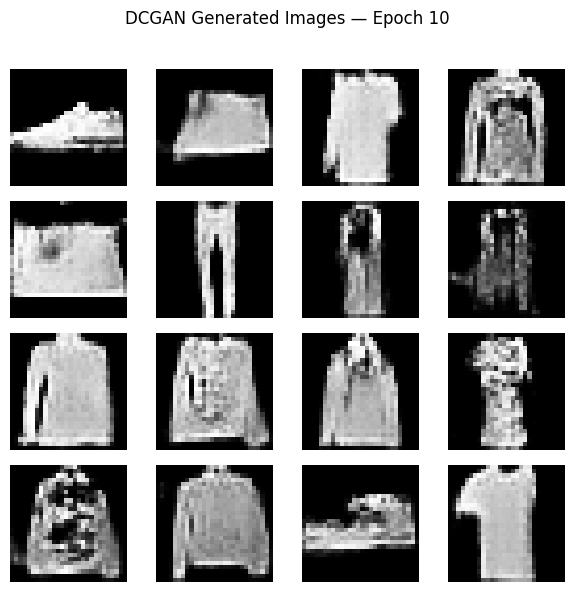

Epoch 11/25 | Generator Loss: 0.7305 | Discriminator Loss: 1.3558
Epoch 12/25 | Generator Loss: 0.7291 | Discriminator Loss: 1.3571
Epoch 13/25 | Generator Loss: 0.7331 | Discriminator Loss: 1.3551
Epoch 14/25 | Generator Loss: 0.7322 | Discriminator Loss: 1.3545
Epoch 15/25 | Generator Loss: 0.7320 | Discriminator Loss: 1.3565


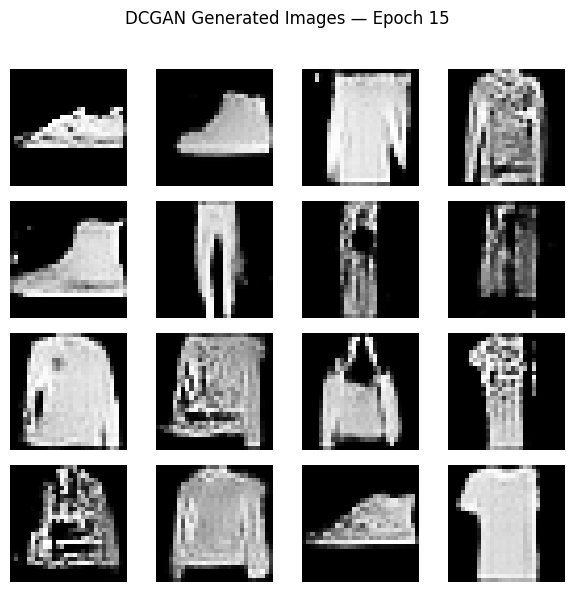

Epoch 16/25 | Generator Loss: 0.7305 | Discriminator Loss: 1.3575
Epoch 17/25 | Generator Loss: 0.7308 | Discriminator Loss: 1.3587
Epoch 18/25 | Generator Loss: 0.7308 | Discriminator Loss: 1.3592
Epoch 19/25 | Generator Loss: 0.7293 | Discriminator Loss: 1.3598
Epoch 20/25 | Generator Loss: 0.7305 | Discriminator Loss: 1.3606


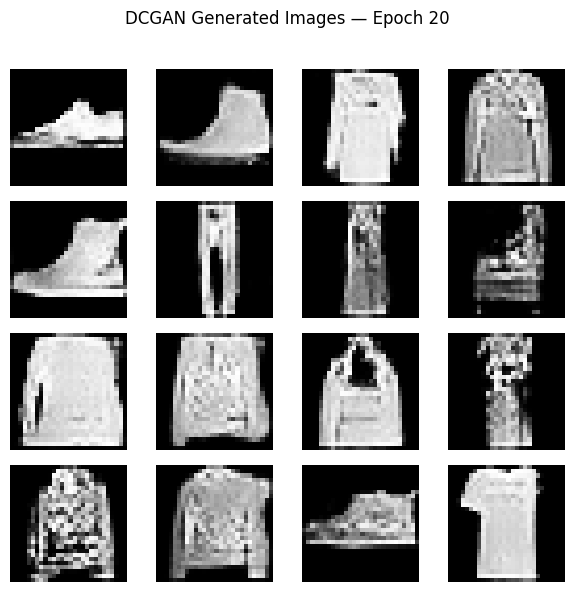

Epoch 21/25 | Generator Loss: 0.7275 | Discriminator Loss: 1.3623
Epoch 22/25 | Generator Loss: 0.7292 | Discriminator Loss: 1.3628
Epoch 23/25 | Generator Loss: 0.7268 | Discriminator Loss: 1.3642
Epoch 24/25 | Generator Loss: 0.7274 | Discriminator Loss: 1.3634
Epoch 25/25 | Generator Loss: 0.7285 | Discriminator Loss: 1.3636


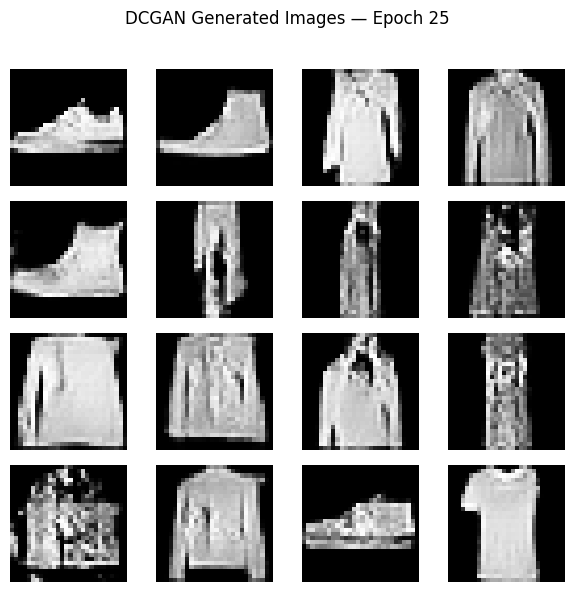

DCGAN training complete.


In [12]:
for epoch in range(1, GAN_EPOCHS + 1):
    g_epoch = []
    d_epoch = []

    for image_batch in fashion_ds:
        g_loss, d_loss = train_step(image_batch)
        g_epoch.append(float(g_loss))
        d_epoch.append(float(d_loss))

    mean_g = float(np.mean(g_epoch))
    mean_d = float(np.mean(d_epoch))

    gan_history["generator"].append(mean_g)
    gan_history["discriminator"].append(mean_d)

    print(
        f"Epoch {epoch:02d}/{GAN_EPOCHS} | "
        f"Generator Loss: {mean_g:.4f} | "
        f"Discriminator Loss: {mean_d:.4f}"
    )

    if epoch % 5 == 0:
        save_generated_grid(epoch)

print("DCGAN training complete.")

## 13. Display All Saved DCGAN Grids

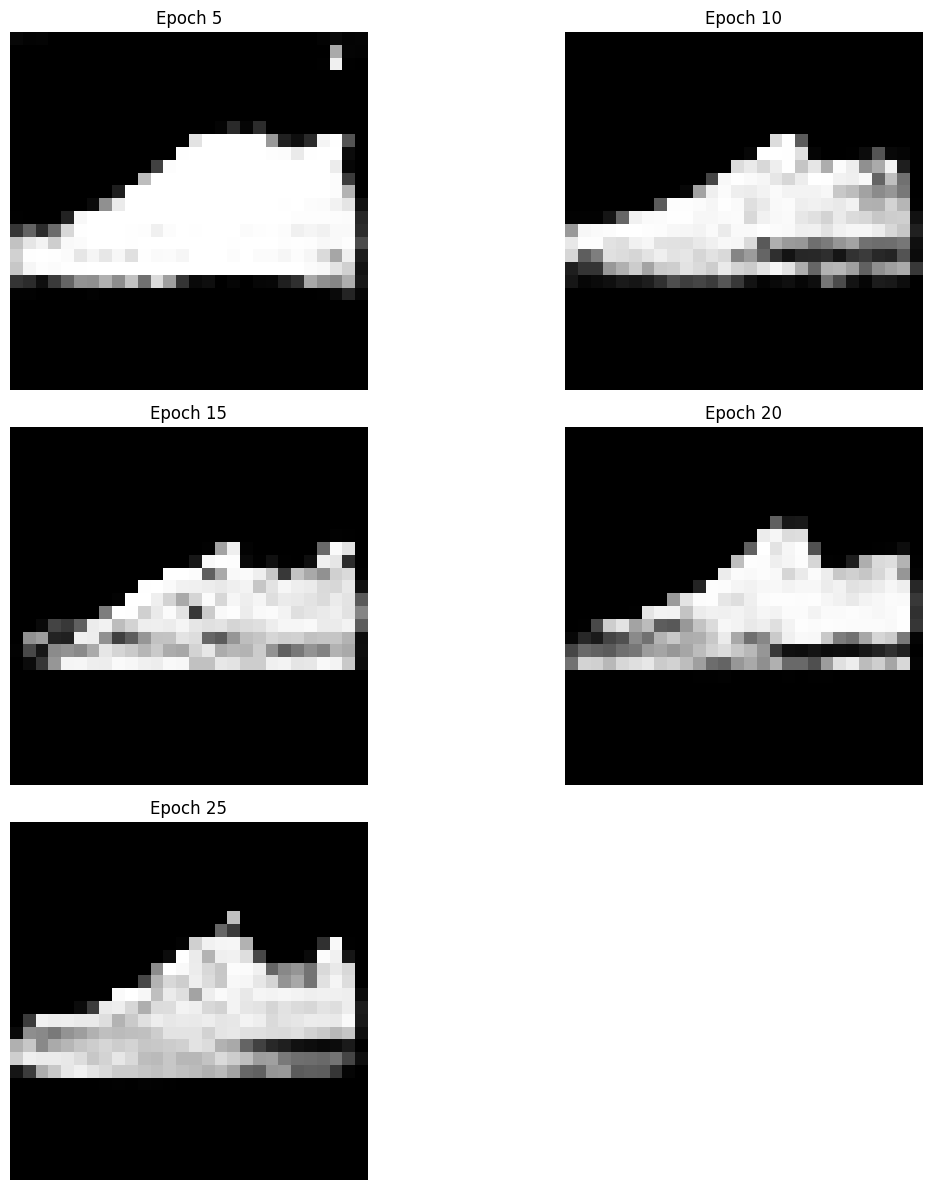

Full 4×4 grids were saved in: gan_vae_outputs


In [13]:
fig = plt.figure(figsize=(12, 12))
for i, epoch in enumerate([5, 10, 15, 20, 25]):
    plt.subplot(3, 2, i + 1)
    grid = gan_snapshots[epoch]
    # Show the first image from each saved fixed-noise grid as a quick progression.
    plt.imshow((grid[0, :, :, 0] + 1) / 2, cmap="gray")
    plt.title(f"Epoch {epoch}")
    plt.axis("off")
plt.tight_layout()
plt.show()

print("Full 4×4 grids were saved in:", OUTPUT_DIR)

## 14. Plot Generator and Discriminator Losses

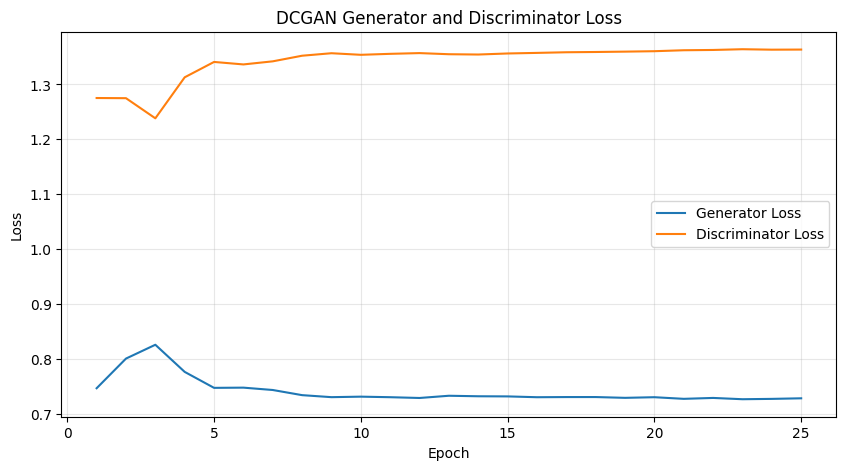

In [14]:
epochs = np.arange(1, GAN_EPOCHS + 1)

plt.figure(figsize=(10, 5))
plt.plot(epochs, gan_history["generator"], label="Generator Loss")
plt.plot(epochs, gan_history["discriminator"], label="Discriminator Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("DCGAN Generator and Discriminator Loss")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

## 15. Generate Images from a Random Noise Vector After Training

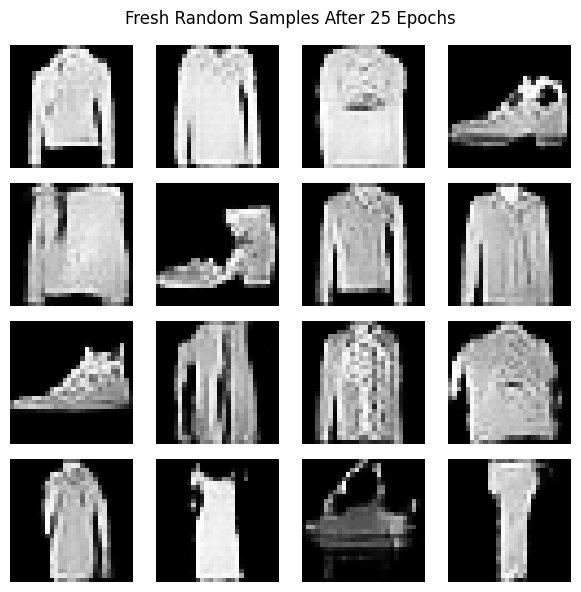

In [15]:
random_noise = tf.random.normal([16, LATENT_DIM_GAN])
random_generated = generator(random_noise, training=False)

plt.figure(figsize=(6, 6))
for i in range(16):
    plt.subplot(4, 4, i + 1)
    plt.imshow((random_generated[i, :, :, 0] + 1) / 2, cmap="gray")
    plt.axis("off")
plt.suptitle("Fresh Random Samples After 25 Epochs")
plt.tight_layout()
plt.show()

## 16. DCGAN Analysis Questions

**Important:** The exact epoch at which recognizable shapes appear can vary because GAN training is stochastic. Use the saved grids from the run above when writing your final observation.

1. **How do the images change from epoch 5 to epoch 25?**  
   At epoch 5, outputs are usually noisy or only weakly structured. Around the middle epochs, outlines and broad clothing-like silhouettes generally begin to emerge. By epoch 25, the samples should have clearer Fashion-MNIST-like structure, although fine details may remain imperfect.

2. **Can you observe instability during training?**  
   Look for sudden changes in loss curves, repeated patterns, noisy outputs, or an epoch where image quality temporarily gets worse. GAN losses do not necessarily decrease smoothly because the generator and discriminator are competing.

3. **At which epoch do cloth-like shapes become recognizable?**  
   Record the first saved grid—5, 10, 15, 20, or 25—where the majority of samples visibly resemble clothing items. This is the most defensible answer for your actual run.

4. **Does the GAN keep improving throughout training, or does improvement stop at some point?**  
   Improvement may slow or plateau. If later grids look similar to earlier ones, or if repeated patterns appear, the generator may have reached a temporary plateau or may be experiencing instability/mode collapse.

**Mode-collapse check:** Compare the 16 images in each grid. If many samples become nearly identical, this is evidence of possible mode collapse.

# Part B — Normal Autoencoder (AE) on MNIST

## 17. Load MNIST Dataset

The normal autoencoder uses sigmoid output because the input images are normalized to `[0, 1]`.

In [16]:
(x_train_mnist, y_train_mnist), (x_test_mnist, y_test_mnist) = keras.datasets.mnist.load_data()

x_train_mnist = x_train_mnist.astype("float32") / 255.0
x_test_mnist = x_test_mnist.astype("float32") / 255.0

x_train_mnist = np.expand_dims(x_train_mnist, -1)
x_test_mnist = np.expand_dims(x_test_mnist, -1)

print("Train:", x_train_mnist.shape)
print("Test:", x_test_mnist.shape)

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Train: (60000, 28, 28, 1)
Test: (10000, 28, 28, 1)


## 18. Display Dataset Before Training

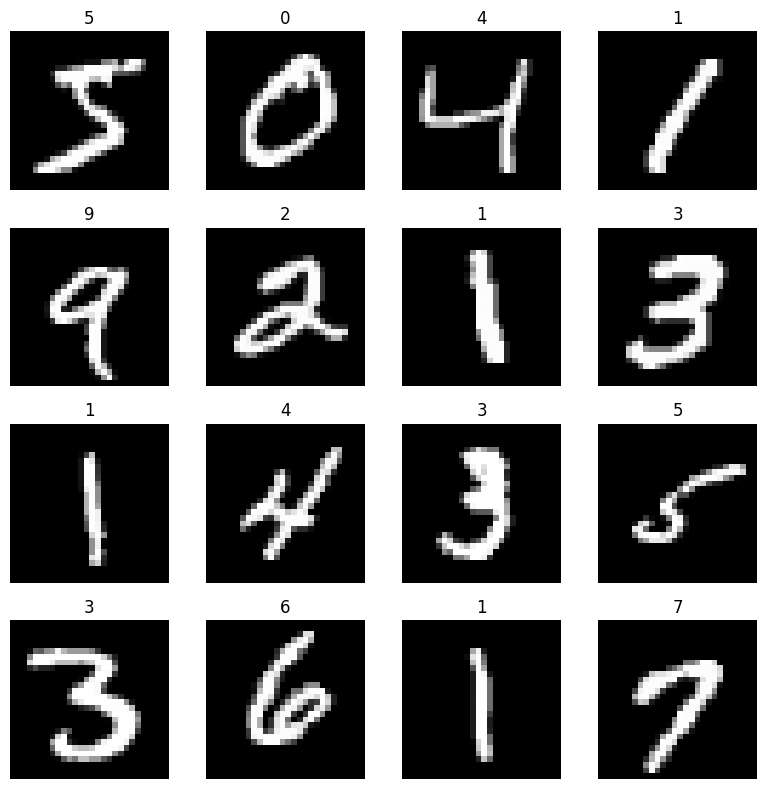

In [17]:
plt.figure(figsize=(8, 8))
for i in range(16):
    plt.subplot(4, 4, i + 1)
    plt.imshow(x_train_mnist[i, :, :, 0], cmap="gray")
    plt.title(str(y_train_mnist[i]))
    plt.axis("off")
plt.tight_layout()
plt.show()

## 19. Build and Train a Normal Autoencoder for 15 Epochs

In [18]:
AE_LATENT_DIM = 2

ae_encoder = keras.Sequential([
    layers.Input(shape=(28, 28, 1)),
    layers.Conv2D(32, 3, strides=2, padding="same", activation="relu"),
    layers.Conv2D(64, 3, strides=2, padding="same", activation="relu"),
    layers.Flatten(),
    layers.Dense(128, activation="relu"),
    layers.Dense(AE_LATENT_DIM)
], name="AE_Encoder")

ae_decoder = keras.Sequential([
    layers.Input(shape=(AE_LATENT_DIM,)),
    layers.Dense(7 * 7 * 64, activation="relu"),
    layers.Reshape((7, 7, 64)),
    layers.Conv2DTranspose(64, 3, strides=2, padding="same", activation="relu"),
    layers.Conv2DTranspose(32, 3, strides=2, padding="same", activation="relu"),
    layers.Conv2D(1, 3, padding="same", activation="sigmoid")
], name="AE_Decoder")

ae_input = keras.Input(shape=(28, 28, 1))
ae_latent = ae_encoder(ae_input)
ae_output = ae_decoder(ae_latent)
autoencoder = keras.Model(ae_input, ae_output, name="Autoencoder")

autoencoder.compile(optimizer="adam", loss="mse")
autoencoder.summary()

ae_history = autoencoder.fit(
    x_train_mnist,
    x_train_mnist,
    epochs=15,
    batch_size=128,
    validation_data=(x_test_mnist, x_test_mnist),
    verbose=1
)

Model: "Autoencoder"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_4 (InputLayer)      │ (None, 28, 28, 1)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ AE_Encoder (Sequential)         │ (None, 2)              │       420,610 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ AE_Decoder (Sequential)         │ (None, 28, 28, 1)      │        65,089 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 485,699 (1.85 MB)

 Trainable params: 485,699 (1.85 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/15
469/469 ━━━━━━━━━━━━━━━━━━━━ 14s 18ms/step - loss: 0.0675 - val_loss: 0.0501
Epoch 2/15
469/469 ━━━━━━━━━━━━━━━━━━━━ 4s 8ms/step - loss: 0.0469 - val_loss: 0.0447
Epoch 3/15
469/469 ━━━━━━━━━━━━━━━━━━━━ 4s 9ms/step - loss: 0.0430 - val_loss: 0.0420
Epoch 4/15
469/469 ━━━━━━━━━━━━━━━━━━━━ 4s 8ms/step - loss: 0.0413 - val_loss: 0.0406
Epoch 5/15
469/469 ━━━━━━━━━━━━━━━━━━━━ 4s 8ms/step - loss: 0.0402 - val_loss: 0.0398
Epoch 6/15
469/469 ━━━━━━━━━━━━━━━━━━━━ 4s 9ms/step - loss: 0.0396 - val_loss: 0.0394
Epoch 7/15
469/469 ━━━━━━━━━━━━━━━━━━━━ 4s 8ms/step - loss: 0.0390 - val_loss: 0.0390
Epoch 8/15
469/469 ━━━━━━━━━━━━━━━━━━━━ 4s 8ms/step - loss: 0.0385 - val_loss: 0.0386
Epoch 9/15
469/469 ━━━━━━━━━━━━━━━━━━━━ 4s 8ms/step - loss: 0.0381 - val_loss: 0.0384
Epoch 10/15
469/469 ━━━━━━━━━━━━━━━━━━━━ 4s 8ms/step - loss: 0.0378 - val_loss: 0.0382
Epoch 11/15
469/469 ━━━━━━━━━━━━━━━━━━━━ 4s 8ms/step - loss: 0.0376 - val_loss: 0.0381
Epoch 12/15
469/469 ━━━━━━━━━━━━━━━━━━━━ 4s 8ms/st

## 20. Plot Autoencoder Loss

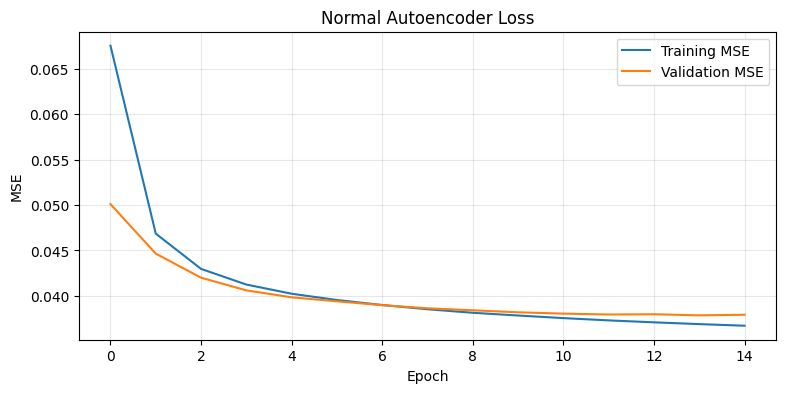

In [19]:
plt.figure(figsize=(9, 4))
plt.plot(ae_history.history["loss"], label="Training MSE")
plt.plot(ae_history.history["val_loss"], label="Validation MSE")
plt.xlabel("Epoch")
plt.ylabel("MSE")
plt.title("Normal Autoencoder Loss")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

## 21. Generate the AE Latent Space

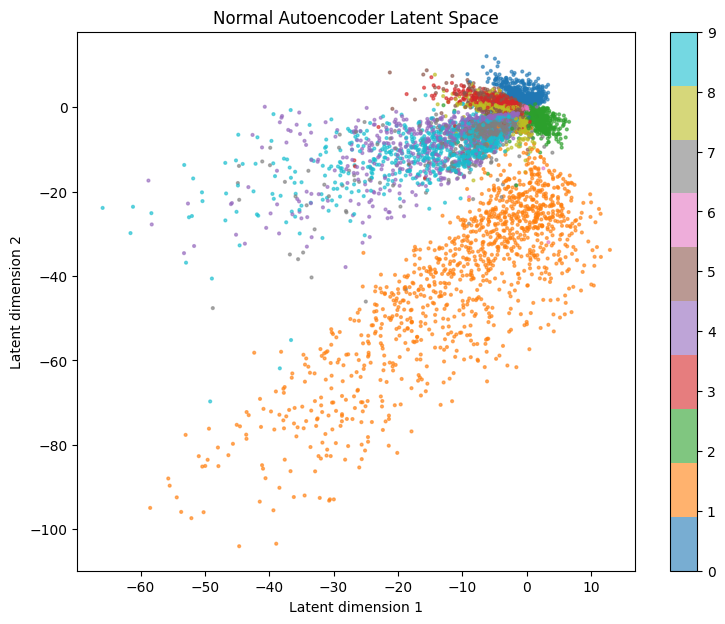

In [20]:
ae_latent_test = ae_encoder.predict(x_test_mnist, batch_size=256, verbose=0)

plt.figure(figsize=(9, 7))
scatter = plt.scatter(
    ae_latent_test[:, 0],
    ae_latent_test[:, 1],
    c=y_test_mnist,
    cmap="tab10",
    s=4,
    alpha=0.6
)
plt.colorbar(scatter, ticks=range(10))
plt.xlabel("Latent dimension 1")
plt.ylabel("Latent dimension 2")
plt.title("Normal Autoencoder Latent Space")
plt.show()

# Part C — Variational Autoencoder (VAE)

The VAE uses the standard probabilistic structure: the encoder outputs `mean` and `log_var`, a sampling layer creates `z`, and the decoder reconstructs the image. Its objective combines reconstruction loss with KL divergence, matching the architecture and loss formulation described by GeeksforGeeks. citeturn0search0

## 22. VAE Encoder with Mean, Log-Variance and Sampling

In [21]:
VAE_LATENT_DIM = 2

class Sampling(layers.Layer):
    def call(self, inputs):
        mean, log_var = inputs
        epsilon = tf.random.normal(shape=tf.shape(mean))
        return mean + tf.exp(0.5 * log_var) * epsilon

vae_encoder_inputs = keras.Input(shape=(28, 28, 1))
x = layers.Conv2D(64, 3, activation="relu", strides=2, padding="same")(vae_encoder_inputs)
x = layers.Conv2D(128, 3, activation="relu", strides=2, padding="same")(x)
x = layers.Flatten()(x)
x = layers.Dense(16, activation="relu")(x)

z_mean = layers.Dense(VAE_LATENT_DIM, name="mean")(x)
z_log_var = layers.Dense(VAE_LATENT_DIM, name="log_var")(x)
z = Sampling()([z_mean, z_log_var])

vae_encoder = keras.Model(
    vae_encoder_inputs,
    [z_mean, z_log_var, z],
    name="VAE_Encoder"
)

vae_encoder.summary()

Model: "VAE_Encoder"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_5       │ (None, 28, 28, 1) │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_5 (Conv2D)   │ (None, 14, 14,    │        640 │ input_layer_5[0]… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_6 (Conv2D)   │ (None, 7, 7, 128) │     73,856 │ conv2d_5[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ flatten_2 (Flatten) │ (None, 6272)      │          0 │ conv2d_6[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_5 (Dense)     │ (None, 16)        │    100,368 │ flatten_2[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ mean (Dense)        │ (None, 2)         │         34 │ dense_5[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ log_var (Dense)     │ (None, 2)         │         34 │ dense_5[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ sampling (Sampling) │ (None, 2)         │          0 │ mean[0][0],       │
│                     │                   │            │ log_var[0][0]     │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 174,932 (683.33 KB)

 Trainable params: 174,932 (683.33 KB)

 Non-trainable params: 0 (0.00 B)

## 23. VAE Decoder

This decoder expands a 2-D latent vector back to 28×28 using transposed convolution layers and a sigmoid output.

In [22]:
vae_decoder_inputs = keras.Input(shape=(VAE_LATENT_DIM,))
x = layers.Dense(7 * 7 * 64, activation="relu")(vae_decoder_inputs)
x = layers.Reshape((7, 7, 64))(x)
x = layers.Conv2DTranspose(128, 3, activation="relu", strides=2, padding="same")(x)
x = layers.Conv2DTranspose(64, 3, activation="relu", strides=2, padding="same")(x)
vae_decoder_outputs = layers.Conv2DTranspose(
    1, 3, activation="sigmoid", padding="same"
)(x)

vae_decoder = keras.Model(
    vae_decoder_inputs,
    vae_decoder_outputs,
    name="VAE_Decoder"
)

vae_decoder.summary()

Model: "VAE_Decoder"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_6 (InputLayer)      │ (None, 2)              │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 3136)           │         9,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ reshape_2 (Reshape)             │ (None, 7, 7, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_transpose_5              │ (None, 14, 14, 128)    │        73,856 │
│ (Conv2DTranspose)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_transpose_6              │ (None, 28, 28, 64)     │        73,792 │
│ (Conv2DTranspose)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_transpose_7              │ (None, 28, 28, 1)      │           577 │
│ (Conv2DTranspose)               │                        │               │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 157,633 (615.75 KB)

 Trainable params: 157,633 (615.75 KB)

 Non-trainable params: 0 (0.00 B)

## 24. Define VAE Loss: Reconstruction + KL Divergence

In [25]:
class VAE(keras.Model):
    def __init__(self, encoder, decoder, **kwargs):
        super().__init__(**kwargs)
        self.encoder = encoder
        self.decoder = decoder
        self.total_loss_tracker = keras.metrics.Mean(name="total_loss")
        self.reconstruction_loss_tracker = keras.metrics.Mean(
            name="reconstruction_loss"
        )
        self.kl_loss_tracker = keras.metrics.Mean(name="kl_loss")

    @property
    def metrics(self):
        return [
            self.total_loss_tracker,
            self.reconstruction_loss_tracker,
            self.kl_loss_tracker
        ]

    def train_step(self, data):
        if isinstance(data, tuple):
            data = data[0]

        with tf.GradientTape() as tape:
            mean, log_var, z = self.encoder(data)
            reconstruction = self.decoder(z)

            reconstruction_loss = tf.reduce_mean(
                tf.reduce_sum(
                    keras.losses.binary_crossentropy(data, reconstruction),
                    axis=(1, 2)
                )
            )

            kl_loss = -0.5 * (
                1 + log_var - tf.square(mean) - tf.exp(log_var)
            )
            kl_loss = tf.reduce_mean(tf.reduce_sum(kl_loss, axis=1))

            total_loss = reconstruction_loss + kl_loss

        grads = tape.gradient(total_loss, self.trainable_weights)
        self.optimizer.apply_gradients(zip(grads, self.trainable_weights))

        self.total_loss_tracker.update_state(total_loss)
        self.reconstruction_loss_tracker.update_state(reconstruction_loss)
        self.kl_loss_tracker.update_state(kl_loss)

        return {
            "loss": self.total_loss_tracker.result(),
            "reconstruction_loss": self.reconstruction_loss_tracker.result(),
            "kl_loss": self.kl_loss_tracker.result()
        }

vae = VAE(vae_encoder, vae_decoder)
vae.compile(optimizer=keras.optimizers.Adam())


## 25. Train the VAE for 20 Epochs

In [27]:
# Train the VAE for 20 epochs

vae_history = vae.fit(
    x_train_mnist,
    epochs=20,
    batch_size=128,
    verbose=1
)

Epoch 1/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 6s 13ms/step - kl_loss: 0.0048 - loss: 206.3081 - reconstruction_loss: 206.3034
Epoch 2/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 7s 14ms/step - kl_loss: 0.0033 - loss: 206.2739 - reconstruction_loss: 206.2706
Epoch 3/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 7s 14ms/step - kl_loss: 0.0022 - loss: 206.2476 - reconstruction_loss: 206.2454
Epoch 4/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 6s 13ms/step - kl_loss: 0.0019 - loss: 206.2355 - reconstruction_loss: 206.2335
Epoch 5/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 6s 13ms/step - kl_loss: 0.0015 - loss: 206.2199 - reconstruction_loss: 206.2186
Epoch 6/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 6s 12ms/step - kl_loss: 0.0014 - loss: 206.2178 - reconstruction_loss: 206.2165
Epoch 7/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 6s 12ms/step - kl_loss: 0.0011 - loss: 206.1948 - reconstruction_loss: 206.1937
Epoch 8/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 6s 12ms/step - kl_loss: 8.8008e-04 - loss: 206.1890 - reconstruction_loss: 206.1881
Epoch 9/20
469/469 ━━━━━━━━━━━━━━━━━

## 26. Plot VAE Total, Reconstruction and KL Losses

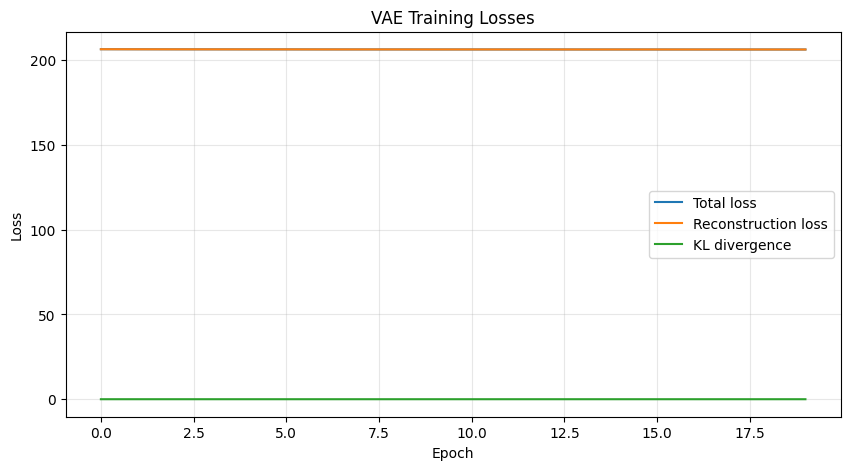

In [28]:
plt.figure(figsize=(10, 5))
plt.plot(vae_history.history["loss"], label="Total loss")
plt.plot(vae_history.history["reconstruction_loss"], label="Reconstruction loss")
plt.plot(vae_history.history["kl_loss"], label="KL divergence")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("VAE Training Losses")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

## 27. Reconstruct Test Images Using VAE

Original images are shown on top and reconstructed images on the bottom.

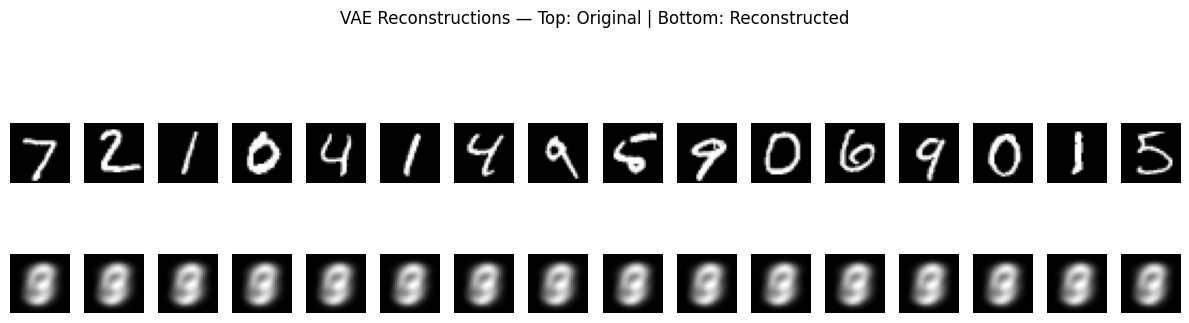

In [29]:
z_mean_test, z_log_var_test, z_test = vae_encoder.predict(
    x_test_mnist[:16], verbose=0
)
vae_reconstructions = vae_decoder.predict(z_test, verbose=0)

plt.figure(figsize=(12, 4))
for i in range(16):
    plt.subplot(2, 16, i + 1)
    plt.imshow(x_test_mnist[i, :, :, 0], cmap="gray")
    plt.axis("off")

    plt.subplot(2, 16, 16 + i + 1)
    plt.imshow(vae_reconstructions[i, :, :, 0], cmap="gray")
    plt.axis("off")

plt.suptitle("VAE Reconstructions — Top: Original | Bottom: Reconstructed")
plt.tight_layout()
plt.show()

## 28. Show the VAE Latent Space

A good 2-D VAE should produce a relatively smooth, compact latent space rather than completely scattered, disconnected points.

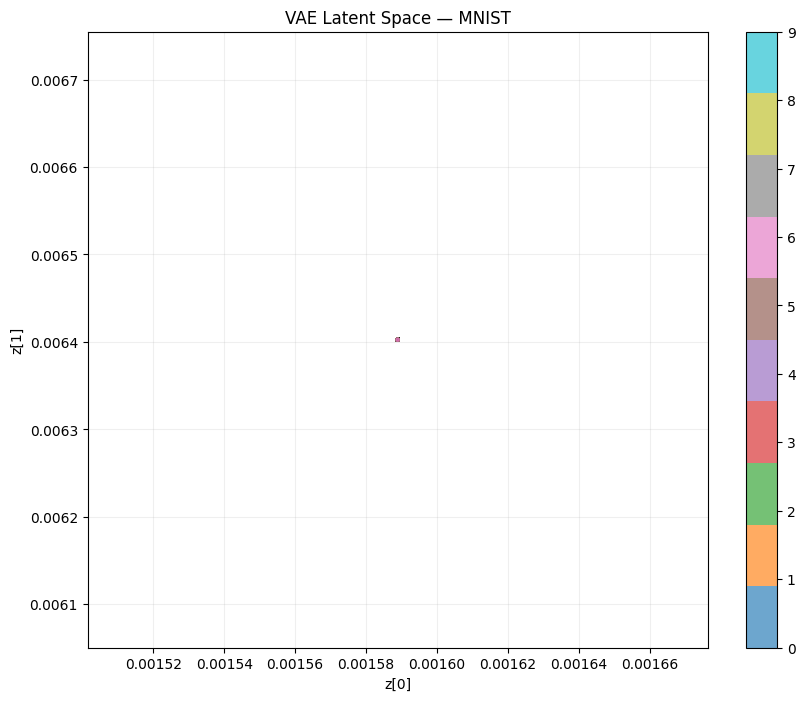

In [30]:
z_mean_all, _, _ = vae_encoder.predict(x_test_mnist, batch_size=256, verbose=0)

plt.figure(figsize=(10, 8))
scatter = plt.scatter(
    z_mean_all[:, 0],
    z_mean_all[:, 1],
    c=y_test_mnist,
    cmap="tab10",
    s=5,
    alpha=0.65
)
cbar = plt.colorbar(scatter, ticks=range(10))
cbar.ax.set_yticklabels([
    "0", "1", "2", "3", "4", "5", "6", "7", "8", "9"
])
plt.xlabel("z[0]")
plt.ylabel("z[1]")
plt.title("VAE Latent Space — MNIST")
plt.grid(alpha=0.2)
plt.show()

## 29. Generate Digits Across the Latent Space

The following grid decodes regularly spaced points between the observed latent-space range. This demonstrates how a VAE can generate continuous transitions between learned representations.

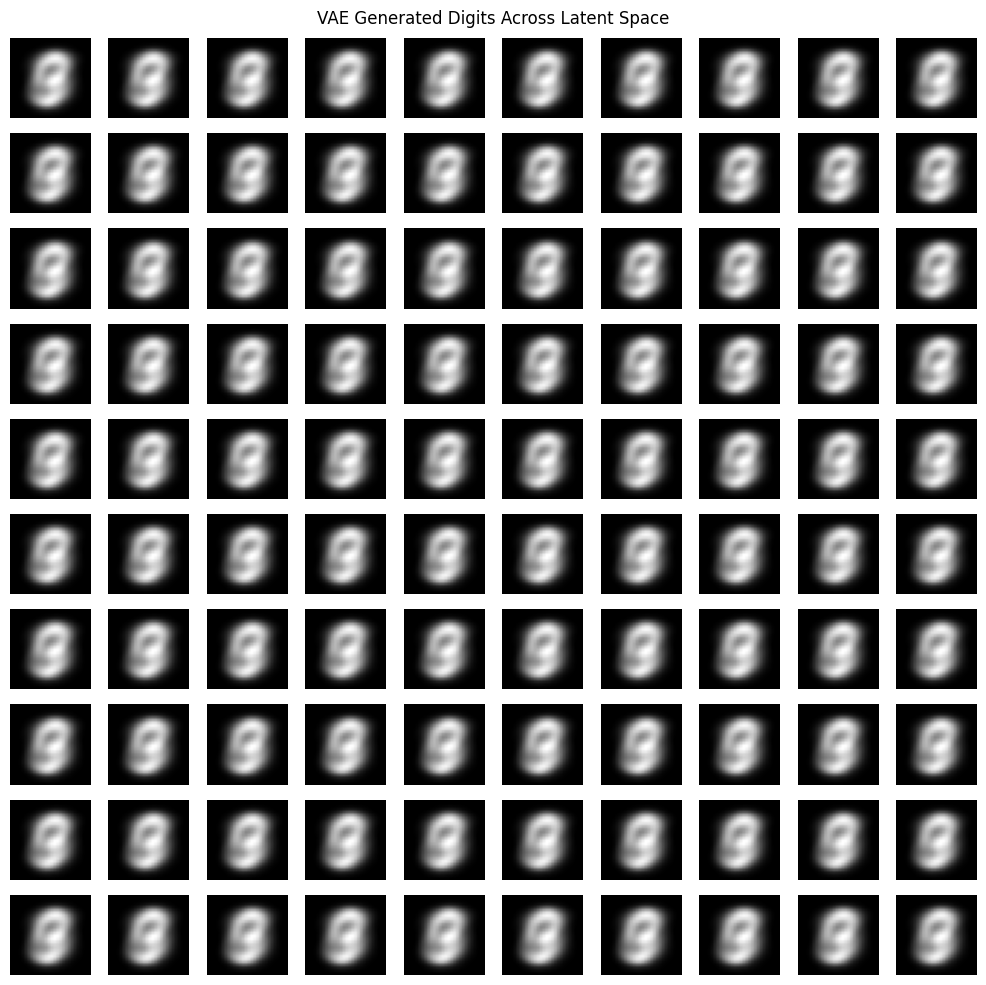

In [31]:
z_min = np.percentile(z_mean_all, 2, axis=0)
z_max = np.percentile(z_mean_all, 98, axis=0)

grid_x = np.linspace(z_min[0], z_max[0], 10)
grid_y = np.linspace(z_min[1], z_max[1], 10)

latent_grid = np.array([[x, y] for y in grid_y[::-1] for x in grid_x], dtype="float32")
generated_grid = vae_decoder.predict(latent_grid, verbose=0)

plt.figure(figsize=(10, 10))
for i in range(100):
    plt.subplot(10, 10, i + 1)
    plt.imshow(generated_grid[i, :, :, 0], cmap="gray")
    plt.axis("off")
plt.suptitle("VAE Generated Digits Across Latent Space")
plt.tight_layout()
plt.show()

## 30. Generate Images from Extreme Latent Points

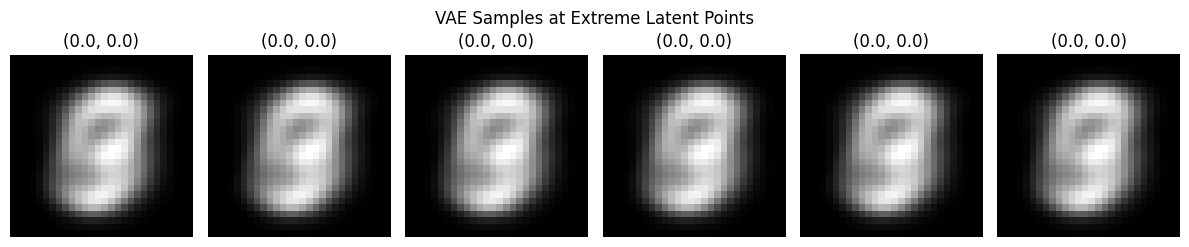

In [32]:
extreme_points = np.array([
    [z_min[0], z_min[1]],
    [z_min[0], z_max[1]],
    [z_max[0], z_min[1]],
    [z_max[0], z_max[1]],
    [z_min[0] * 1.5, z_min[1] * 1.5],
    [z_max[0] * 1.5, z_max[1] * 1.5],
], dtype="float32")

extreme_images = vae_decoder.predict(extreme_points, verbose=0)

plt.figure(figsize=(12, 2.5))
for i in range(len(extreme_points)):
    plt.subplot(1, len(extreme_points), i + 1)
    plt.imshow(extreme_images[i, :, :, 0], cmap="gray")
    plt.title(f"({extreme_points[i,0]:.1f}, {extreme_points[i,1]:.1f})")
    plt.axis("off")
plt.suptitle("VAE Samples at Extreme Latent Points")
plt.tight_layout()
plt.show()

## 31. Take a Point Outside the Learned Latent Space

A point well outside the learned region is decoded to observe how the VAE behaves outside the main data manifold. The result may be blurry, ambiguous, or resemble a distorted digit because the decoder has less training information in this region.

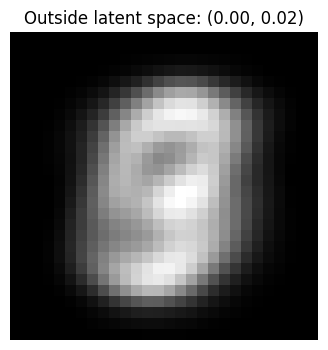

In [33]:
outside_point = np.array([[
    z_max[0] * 2.5,
    z_max[1] * 2.5
]], dtype="float32")

outside_image = vae_decoder.predict(outside_point, verbose=0)[0, :, :, 0]

plt.figure(figsize=(4, 4))
plt.imshow(outside_image, cmap="gray")
plt.title(
    f"Outside latent space: "
    f"({outside_point[0,0]:.2f}, {outside_point[0,1]:.2f})"
)
plt.axis("off")
plt.show()

# 32. Final Short Written Observation

### DCGAN
During the first few epochs, the Fashion-MNIST samples are mostly noisy and lack clear clothing structure. As training progresses, the generator learns broad shapes and begins producing recognizable clothing-like silhouettes. By the later saved epochs, the images generally become more structured, although they may still be blurry and some samples may contain artifacts. The generator and discriminator losses fluctuate rather than decreasing smoothly because they are competing networks. If several generated images become almost identical, this indicates possible mode collapse. Image-quality improvement can also plateau before the final epoch.

### Normal Autoencoder
The normal autoencoder learns a compact representation that can reconstruct MNIST digits. Its 2-D latent representation is useful for visualization, but it is not explicitly forced to follow a smooth probability distribution. Consequently, gaps can exist between clusters, making arbitrary sampling from the latent space less reliable.

### VAE
The VAE learns a probabilistic latent representation using a mean, log-variance and the reparameterization trick. Its total loss combines reconstruction loss and KL divergence. The KL term encourages the latent representation to remain close to a standard normal distribution, which makes sampling and interpolation possible. Reconstructions are often smoother or blurrier than GAN samples, but the latent space is more continuous and suitable for generating new digits.

### Overall conclusion
The practical demonstrates the different strengths of GANs and VAEs. A DCGAN focuses on adversarial image realism and can produce sharper samples but may be unstable. A VAE emphasizes a structured, continuous latent space and reliable sampling, usually at the cost of blurrier reconstructions.